## **Corrective RAG**

Corrective Retrieval-Augmented Generation (Corrective RAG, CRAG)은 답변 생성의 정확도를 향상시키기 위해, 내부 문서의 관련성을 평가하고 보정하는 방법입니다.
<br/>
<br/>
1) Correct: 문서가 관련성이 있을 경우, 불필요한 부분을 제거하는 정제 과정을 거쳐 생성에 사용합니다.

2) Incorrect: 문서가 관련성이 없을 경우 폐기하고, 시스템이 추가 정보를 웹에서 검색합니다.

3) Ambiguous: 문서의 관련성이 불명확한 경우, 검색된 내부 정보와 웹 검색 정보를 결합하여 균형 잡힌 응답을 생성합니다.

## **Initial Setup**

In [ ]:
! pip install --q athina chromadb langgraph pdfplumber faiss-cpu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 4.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.8/228.8 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.1/611.1 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.5/131.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 102.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
! pip install --q athina datasets langchain_community tiktoken langchain-openai langchainhub chromadb langchain langgraph tavily-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.7 MB/s eta 0:00:00


In [3]:
import os
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
os.environ["TAVILY_API_KEY"] = userdata.get('TAVILY_API_KEY')
os.environ['ATHINA_API_KEY'] = userdata.get('ATHINA_API_KEY')

## **Indexing**

In [ ]:
from langchain_community.document_loaders import PDFPlumberLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from typing import List, Annotated

import faiss
import numpy as np
from langchain_community.docstore.in_memory import InMemoryDocstore
from langchain.schema.document import Document
from langchain_community.vectorstores import FAISS

from langchain_core.output_parsers import StrOutputParser
from langchain_openai import OpenAIEmbeddings, ChatOpenAI

from abc import ABC, abstractmethod
from operator import itemgetter
from langchain import hub

class RetrievalChain(ABC):
    def __init__(self):
        self.source_uri = None
        self.k = 10
        self.model_name = "gpt-4o-mini"

    @abstractmethod
    def load_documents(self, source_uris):
        """loader를 사용하여 문서를 로드합니다."""
        pass

    @abstractmethod
    def create_text_splitter(self):
        """text splitter를 생성합니다."""
        pass

    def split_documents(self, docs, text_splitter):
        """text splitter를 사용하여 문서를 분할합니다."""
        return text_splitter.split_documents(docs)

    def create_embedding(self):
        return OpenAIEmbeddings(model="text-embedding-3-small")

    def create_vectorstore(self, split_docs):
        embedding_model = self.create_embedding()

        # 문서에서 텍스트 추출 및 임베딩 생성
        texts = [doc.page_content for doc in split_docs]
        embeddings = embedding_model.embed_documents(texts)

        # numpy array로 명시적 변환
        embeddings_array = np.array(embeddings, dtype=np.float32)

        # FAISS 인덱스 초기화 (명확한 dimension 입력)
        dimension = embeddings_array.shape[1]
        index = faiss.IndexFlatL2(dimension)

        # index와 docstore_id 연결
        index_to_docstore_id = {i: str(i) for i in range(len(split_docs))}
        docstore = InMemoryDocstore({str(i): doc for i, doc in enumerate(split_docs)})

        # FAISS 벡터스토어 명시적으로 생성
        vectorstore = FAISS(
            embedding_function=embedding_model,
            index=index,
            docstore=docstore,
            index_to_docstore_id=index_to_docstore_id
        )

        # 문서 임베딩 명시적 추가
        vectorstore.add_embeddings(
            text_embeddings=list(zip(texts, embeddings))
        )

        return vectorstore

    def create_retriever(self, vectorstore):
        # retriever 생성
        dense_retriever = vectorstore.as_retriever(
            search_type="similarity", search_kwargs={"k": self.k}
        )
        return dense_retriever

    def create_model(self):
        return ChatOpenAI(model_name=self.model_name, temperature=0)

    def create_prompt(self):
        return hub.pull("teddynote/rag-prompt")

    @staticmethod
    def format_docs(docs):
        return "\n".join(docs)

    def create_chain(self):
        docs = self.load_documents(self.source_uri)
        text_splitter = self.create_text_splitter()
        split_docs = self.split_documents(docs, text_splitter)
        self.vectorstore = self.create_vectorstore(split_docs)
        self.retriever = self.create_retriever(self.vectorstore)
        model = self.create_model()
        prompt = self.create_prompt()
        self.chain = (
            {"question": itemgetter("question"), "context": itemgetter("context")}
            | prompt
            | model
            | StrOutputParser()
        )
        return self
def format_docs(docs):
    return "\n".join(
        [
            f"<document><content>{doc.page_content}</content><source>{doc.metadata['source']}</source><page>{int(doc.metadata['page'])+1}</page></document>"
            for doc in docs
        ]
    )


def format_searched_docs(docs):
    return "\n".join(
        [
            f"<document><content>{doc['content']}</content><source>{doc['url']}</source></document>"
            for doc in docs
        ]
    )


def format_task(tasks):
    # 결과를 저장할 빈 리스트 생성
    task_time_pairs = []

    # 리스트를 순회하면서 각 항목을 처리
    for item in tasks:
        # 콜론(:) 기준으로 문자열을 분리
        task, time_str = item.rsplit(":", 1)
        # '시간' 문자열을 제거하고 정수로 변환
        time = int(time_str.replace("시간", "").strip())
        # 할 일과 시간을 튜플로 만들어 리스트에 추가
        task_time_pairs.append((task, time))

    # 결과 출력
    return task_time_pairs

class PDFRetrievalChain(RetrievalChain):
    def __init__(
        self,
        source_uri: Annotated[str, "Source URI"],
        model_name="gpt-4o-mini",
        k: int = 6,
    ):
        self.source_uri = source_uri
        self.k = k
        self.model_name = model_name

    def load_documents(self, source_uris: List[str]):
        docs = []
        for source_uri in source_uris:
            loader = PDFPlumberLoader(source_uri)
            docs.extend(loader.load())

        return docs

    def format_docs(self, docs):
        return format_docs(docs)

    def create_text_splitter(self):
        return RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=0)

    def create_vectorstore(self, split_docs):
        embedding_model = self.create_embedding()
        embeddings = embedding_model.embed_documents([doc.page_content for doc in split_docs])

        # 여기서 추가적으로 디버깅 출력
        print("Embeddings type:", type(embeddings))
        print("Number of embeddings generated:", len(embeddings))
        print("Embedding dimension of the first document:", len(embeddings[0]))

        # 만약 embeddings가 numpy가 아니라면 변환
        embeddings_array = np.array(embeddings, dtype=np.float32)
        print("Shape of embeddings array:", embeddings_array.shape)

        return FAISS.from_embeddings(
            text_embeddings=list(zip([doc.page_content for doc in split_docs], embeddings)),
            embedding=embedding_model
        )

In [5]:
# load embedding model
from langchain_openai import OpenAIEmbeddings
embeddings = OpenAIEmbeddings()

In [6]:
# PDF 문서를 로드
pdf = PDFRetrievalChain(["/content/[ROA]당근마켓_221118.pdf"]).create_chain()

# retriever 와 chain을 생성
pdf_retriever = pdf.retriever
documents = pdf.chain

/usr/local/lib/python3.11/dist-packages/langsmith/client.py:253: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [7]:
# split documents
# from langchain.text_splitter import RecursiveCharacterTextSplitter
# text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=0)
# documents = text_splitter.split_documents(documents)

In [8]:
# # create vectorstore
# from langchain.vectorstores import Chroma
# vectorstore = Chroma.from_documents(documents, embeddings)

## **Retriever**

In [9]:
# # create retriever
# retriever = vectorstore.as_retriever()

## **Document Grader**
문서 평가기는 주어진 Query와 Document 관련이 있는지를 평가합니다.

In [10]:
# create grader for doc retriever
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_openai import ChatOpenAI

# defining a data class for the grader
class GradeDocuments(BaseModel):
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

# LLM with function call
llm = ChatOpenAI(model='gpt-4o',temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# Prompt for the grader
system = """You are a grader assessing relevance of a retrieved document to a user question. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

retrieval_grader = grade_prompt | structured_llm_grader

/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py:3553: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)
/usr/local/lib/python3.11/dist-packages/langchain_openai/chat_models/base.py:1377: UserWarning: Received a Pydantic BaseModel V1 schema. This is not supported by method="json_schema". Please use method="function_calling" or specify schema via JSON Schema or Pydantic V2 BaseModel. Overriding to method="function_calling".
  

In [11]:
# run grader
question = "당근이 영업손실이 높은 이유는?"
# docs = retriever.get_relevant_documents(question)
docs = pdf_retriever.invoke(question)

print(retrieval_grader.invoke({"question": question, "document": docs}))

binary_score='yes'


## **RAG Chain**

In [12]:
# create document chain
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain.prompts import ChatPromptTemplate

template = """"
You are a helpful assistant that answers questions based on the following context.'
Use the provided context to answer the question.
Context: {context}
Question: {question}
Answer:

"""

# prompt = ChatPromptTemplate.from_template(template)
prompt = hub.pull("teddynote/rag-prompt")
llm = ChatOpenAI(temperature=0)

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)


rag_chain = prompt | llm | StrOutputParser()

/usr/local/lib/python3.11/dist-packages/langsmith/client.py:253: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [13]:
# response
generation = rag_chain.invoke({"context": docs, "question": question})
generation

'영업손실이 높은 이유는, 영업비용 증가로 2020년 대비 142.4% 증가한 609억 8,000만원 중 인건비와 광고 선전비가 가장 큰 부분을 차지했기 때문입니다.\n\n**Source**\n- /content/[ROA]당근마켓_221118.pdf (page 9)'

## **Question Re-writer**

In [14]:
# from langchain_core.prompts import ChatPromptTemplate
# from langchain_core.output_parsers import StrOutputParser
# from langchain_openai import ChatOpenAI


# # LLM 설정
# llm = ChatOpenAI(model='gpt-4o', temperature=0)

# # Query Rewrite 프롬프트
# system = """You a question re-writer that converts an input question to a better version that is optimized
# for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""

# re_write_prompt = ChatPromptTemplate.from_messages(
#     [
#         ("system", system),
#         (
#             "human",
#             "Here is the initial question: \n\n {question} \n Formulate an improved question.",
#         ),
#     ]
# )

# question_rewriter = re_write_prompt | llm | StrOutputParser()

In [15]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

# LLM 설정
llm = ChatOpenAI(model='gpt-4o', temperature=0)

# Query Rewrite 프롬프트
system = """당신은 웹 검색 최적화를 위해 입력된 질문을 더 나은 형태로 재작성하는 질문 재작성기입니다.
입력을 주의 깊게 읽고, 그 의미와 의도를 고려하여 최적의 질문으로 변환하세요."""

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "초기 질문은 다음과 같습니다: \n\n {question} \n\n더 나은 질문으로 재작성해 주세요.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()

In [16]:
print(f'[원본 질문]: "{question}"')
print("[쿼리 재작성]:", question_rewriter.invoke({"question": question}))

[원본 질문]: "당근이 영업손실이 높은 이유는?"
[쿼리 재작성]: 당근의 영업손실이 큰 원인은 무엇인가요?


## **Web Search**

In [17]:
# web search
from langchain_community.tools.tavily_search import TavilySearchResults
web_search_tool = TavilySearchResults(k=3)

In [18]:
# # web search test
# web_search_tool.invoke('USA election 2024')

In [19]:
# web search 실행
results = web_search_tool.invoke({"query": question})
print(results)

[{'title': '기업가치 3조 당근마켓, 작년 영업손 540억... 적자폭 더 커졌다', 'url': 'https://biz.chosun.com/distribution/channel/2023/04/11/YDHQXE5OIJBABF5HGPE4Q2AKKA/', 'content': "이유는 수익 모델이 '광고'에 한정돼서다. 지난해 당근마켓 매출 중 광고 수익 비중은 99.2%였다. 그래픽=정서희. 지난해 2월 출범한 당근페이도", 'score': 0.81595254}, {'title': '엄청난 적자에 직면한 당근마켓의 미래.. 다소 부정적 관점입니다', 'url': 'https://blog.naver.com/guruma_nc/223076051816', 'content': '매출보다도 영업 손실이 더 크다. 개발자 초봉이 6500만원에 달하는 등 지나치게 높아진 인건비가 초유의 적자 사태로 이어진 것으로 전해진다. 금융', 'score': 0.7185356}, {'title': "'당근마켓' 순손실이 3배 늘어난 이유 | 블로터 - Daum", 'url': 'https://v.daum.net/v/Eu1verAV4Z?dmp_id=hamny-Eu1verAV4Z', 'content': '·당근마켓 순손실이 지난해 전년대비 3배 가까이 증가했는데요. 당근서비스, 당근페이 등 자회사들의 손실이 컸기 때문입니다. ·지난해 당근마켓의 매출은', 'score': 0.70702106}, {'title': "“초봉 6500만원이라니” 동네 사람 다하는 '당근마켓' 엄청난 적자 알고 ...", 'url': 'https://biz.heraldcorp.com/article/3105577', 'content': "당근마켓은 2015년 설립 이후 계속 적자를 기록해왔다. 회사가 커지면서 영업손실은 매년 불어났다. 이용자수가 폭발적으로 증가하며 '국민 필수앱'이", 'score': 0.66308063}, {'title': "'국민 앱' 당근, 영업이익보다 '중요한 숫자' 따로 있다는데 [

## **Create Graph**
### **Define Graph State**

In [20]:
from typing import List
from typing_extensions import TypedDict

class GraphState(TypedDict):
    question: str
    generation: str
    web_search: str
    documents: List[str]

### **Build Graph**

In [21]:
# graph steps
from langchain.schema import Document

# retrieval node
def retrieve(state):

    print("---RETRIEVE---")
    question = state["question"]

    # retrieval
    documents = pdf_retriever.invoke(question)
    return {"documents": documents, "question": question}

# generation node
def generate(state):

    print("---GENERATE---")
    question = state["question"]
    documents = state["documents"]

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}

# check_relevance node
def grade_documents(state):

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state["documents"]

    # Score each document
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue
    return {"documents": filtered_docs, "question": question, "web_search": web_search}

# question re-writer node
def query_rewrite(state):
    print("---REWRITE QUERY---")
    question = state["question"]

    better_question = question_rewriter.invoke({"question": question})
    return {"question": better_question}

# node function for web search
def web_search(state):

    print("---WEB SEARCH---")
    question = state["question"]
    documents = state["documents"]

    # Web search
    docs = web_search_tool.invoke({"query": question})
    web_results = "\n".join([d["content"] for d in docs])
    web_results = Document(page_content=web_results)
    documents.append(web_results)

    return {"documents": documents, "question": question}

# decision node
def decide_to_generate(state):

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        print("---DECISION: WEB SEARCH---")
        return "query_rewrite"
    else:
        print("---DECISION: GENERATE---")
        return "generate"

## **Graph**

In [22]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# node 선언
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
workflow.add_node("query_rewrite", query_rewrite)
workflow.add_node("web_search_node", web_search)

# Graph 조합
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "query_rewrite": "query_rewrite",
        "generate": "generate",
    },
)

workflow.add_edge("query_rewrite", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

# Compile
app = workflow.compile()

In [23]:
import random
from IPython.display import Image, display
from langgraph.graph.state import CompiledStateGraph
from dataclasses import dataclass


@dataclass
class NodeStyles:
    default: str = (
        "fill:#45C4B0, fill-opacity:0.3, color:#23260F, stroke:#45C4B0, stroke-width:1px, font-weight:bold, line-height:1.2"  # 기본 색상
    )
    first: str = (
        "fill:#45C4B0, fill-opacity:0.1, color:#23260F, stroke:#45C4B0, stroke-width:1px, font-weight:normal, font-style:italic, stroke-dasharray:2,2"  # 점선 테두리
    )
    last: str = (
        "fill:#45C4B0, fill-opacity:1, color:#000000, stroke:#45C4B0, stroke-width:1px, font-weight:normal, font-style:italic, stroke-dasharray:2,2"  # 점선 테두리
    )


def visualize_graph(graph, xray=False):
    """
    mermaid.ink를 활용한 lagngraph Grpah 만들기

    CompiledStateGraph 객체를 시각화하여 표시
    """
    try:
        # 그래프 시각화
        if isinstance(graph, CompiledStateGraph):
            display(
                Image(
                    graph.get_graph(xray=xray).draw_mermaid_png(
                        background_color="white",
                        node_colors=NodeStyles(),
                    )
                )
            )
    except Exception as e:
        print(f"[ERROR] Visualize Graph Error: {e}")


def generate_random_hash():
    return f"{random.randint(0, 0xffffff):06x}"

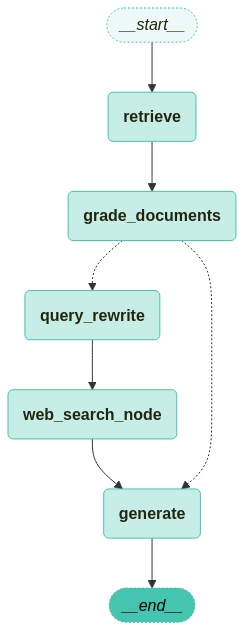

In [24]:
visualize_graph(app)

In [25]:
# Test1 : 내부 Documnet와 연관있는 질문
from pprint import pprint

inputs = {"question": "당근이 영업손실이 높은 이유는?"}
for output in app.stream(inputs):
    for key, value in output.items():
        pprint(f"Node '{key}':")
    print("\n---------------------\n")

pprint(value["generation"])

---RETRIEVE---
"Node 'retrieve':"

---------------------

---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: WEB SEARCH---
"Node 'grade_documents':"

---------------------

---REWRITE QUERY---
"Node 'query_rewrite':"

---------------------

---WEB SEARCH---
"Node 'web_search_node':"

---------------------

---GENERATE---
"Node 'generate':"

---------------------

('영업손실의 큰 원인은 영업비용 증가로, 인건비 및 광고 선전비가 주요 부분을 차지했으며, 직원수 증가와 사옥 임차료 증가도 영향을 '
 '미쳤습니다.\n'
 '\n'
 '**Source**\n'
 '- /content/[ROA]당근마켓_221118.pdf, Page 9')


In [26]:
# Test2 : 내부 Documnet와 연관없는 질문
inputs = {"question": "Corrective RAG는 뭔가요?"}
for output in app.stream(inputs):
    for key, value in output.items():
        pprint(f"Node '{key}':")
    print("\n---------------------\n")

pprint(value["generation"])

---RETRIEVE---
"Node 'retrieve':"

---------------------

---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: WEB SEARCH---
"Node 'grade_documents':"

---------------------

---REWRITE QUERY---
"Node 'query_rewrite':"

---------------------

---WEB SEARCH---
"Node 'web_search_node':"

---------------------

---GENERATE---
"Node 'generate':"

---------------------

('Corrective RAG는 검색된 문서의 신뢰성을 평가하고 수정하는 기능을 수행하며, 잘못된 정보를 개선하거나 대체하는 수정 조치를 '
 '취합니다.\n'
 '\n'
 '**Source**\n'
 '- Document: Page 3')


## **Preparing Data for Evaluation**

In [27]:
# Qustion, Context, Response를 저장하는 DF 생성
# https://www.donga.com/news/Economy/article/all/20250305/131152327/2
inputs = {"question": "당근마켓의 '당근 실명제' 논란은 어떻게 마무리되었으며, 이 결정이 개인 판매자들에게 어떤 영향을 미쳤나요?"}
outputs = []
expected_response = "공정거래위원회는 당근마켓이 전자상거래법상 소비자 보호 의무를 어겼다는 의혹에 대해 위법 소지는 인정하였으나, 개인정보 보호와 혁신 저해 우려 등을 고려해 사건을 종료하기로 결정했습니다. 그 결과, 당근마켓의 개인 판매자들은 기존과 같이 익명으로 거래를 계속할 수 있게 되어, 실명제 논란에 사실상 마침표가 찍혔습니다."

for output in app.stream(inputs):
    for key, value in output.items():
        if key == "generate":
            question = value["question"]
            documents = value["documents"]
            generation = value["generation"]

            context = "\n".join(doc.page_content for doc in documents)

            # Append the result
            outputs.append({
                "query": question,
                "context": context,
                "response": generation,
                "expected_response": expected_response
            })


---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: WEB SEARCH---
---REWRITE QUERY---
---WEB SEARCH---
---GENERATE---


In [28]:
# DataFrame
import pandas as pd
df = pd.DataFrame(outputs)

In [29]:
df

,query,context,response,expected_response
0,"당근마켓의 '당근 실명제' 논란은 어떤 결과로 이어졌으며, 이 결정이 개인 판매자들...","5년간 이어진 '당근 실명제' 논란에 사실상 마침표를 찍은 것으로, 개인 판매자들은...","'당근 실명제' 논란은 개인 판매자들에게 미친 영향으로, 개인 판매자들은 익명으로 ...",공정거래위원회는 당근마켓이 전자상거래법상 소비자 보호 의무를 어겼다는 의혹에 대해 ...


In [30]:
# df -> dict
df_dict = df.to_dict(orient='records')

# dict -> list
for record in df_dict:
    if not isinstance(record.get('context'), list):
        if record.get('context') is None:
            record['context'] = []
        else:
            record['context'] = [record['context']]

## **Evaluation in Athina AI**

Athina AI에서의 평가

여기서는 Context Precision 평가를 사용할 것입니다. 이는 컨텍스트 내에 존재하는 모든 실제 관련 항목들이 더 높은 순위에 있는지를 평가합니다. 자세한 내용은 문서를 참고하시기 바랍니다.


In [31]:
# Athina
from athina.keys import AthinaApiKey, OpenAiApiKey
OpenAiApiKey.set_key(os.getenv('OPENAI_API_KEY'))
AthinaApiKey.set_key(os.getenv('ATHINA_API_KEY'))

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_config.py:345: UserWarning: Valid config keys have changed in V2:
* 'fields' has been removed
  warnings.warn(message, UserWarning)
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:502: UserWarning: <built-in function any> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warn(


In [32]:
# dataset 로드
from athina.loaders import Loader
dataset = Loader().load_dict(df_dict)

In [33]:
# evaluate
from athina.evals import RagasContextPrecision
RagasContextPrecision(model="gpt-4o").run_batch(data=dataset).to_df()

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

You can view your dataset at: https://app.athina.ai/develop/49ccb563-0efd-4c8a-8064-7b17410ad162


,query,context,response,expected_response,display_name,failed,grade_reason,runtime,model,ragas_context_precision
0,"당근마켓의 '당근 실명제' 논란은 어떤 결과로 이어졌으며, 이 결정이 개인 판매자들에게 미친 영향은 무엇인가요?","[5년간 이어진 '당근 실명제' 논란에 사실상 마침표를 찍은 것으로, 개인 판매자들은 지금처럼 익명으로 당근마켓을 이용할 수 있게 됐다. 5일 공정위는\n5년간 이어진 '당근 실명제' 논란에 사실상 마침표를 찍은 것으로, 개인 판매자들은 지금처럼 익명으로 당근마켓을 이용할 수 있게 됐다. 5일 공정위는\n[세종=이데일리 하상렬 기자] 공정거래위원회가 범죄악용 우려로 논란이 됐던 '당근마켓 실명제' 논란에 종지부를 찍었다. 개인판매자의 경우 기존처럼\n공정거래위원회가 범죄악용 우려로 논란이 됐던 '당근마켓 실명제' 논란에 종지부를 찍었다. 개인판매자의 경우 기존처럼 당근마켓을 활용할 수\n이에 공정위는 당근마켓의 행위가 전자상거래법 제20조 제2항에 따른 통신판매중개업자의 의무를 위반한 행위로 보아 이행명령을 부과하기로 하였습니다.]","'당근 실명제' 논란은 개인 판매자들에게 미친 영향으로, 개인 판매자들은 익명으로 당근마켓을 계속 이용할 수 있게 되었습니다.\n\n**Source**\n- Document(Page 1)","공정거래위원회는 당근마켓이 전자상거래법상 소비자 보호 의무를 어겼다는 의혹에 대해 위법 소지는 인정하였으나, 개인정보 보호와 혁신 저해 우려 등을 고려해 사건을 종료하기로 결정했습니다. 그 결과, 당근마켓의 개인 판매자들은 기존과 같이 익명으로 거래를 계속할 수 있게 되어, 실명제 논란에 사실상 마침표가 찍혔습니다.",Ragas Context Precision,None,This metric evaluates whether all of the ground-truth relevant items present in the context are ranked higher or not. Ideally all the relevant chunks must appear at the top ranks,4322,gpt-4o,1.0


from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['index']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'index'}, axis=1)
              .sort_values('index', ascending=True))
  xs = counted['index']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_0.sort_values('index', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('index')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['runtime']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'runtime'}, axis=1)
              .sort_values('runtime', ascending=True))
  xs = counted['runtime']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_1.sort_values('runtime', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('runtime')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['ragas_context_precision']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'ragas_context_precision'}, axis=1)
              .sort_values('ragas_context_precision', ascending=True))
  xs = counted['ragas_context_precision']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_2.sort_values('ragas_context_precision', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('ragas_context_precision')
_ = plt.ylabel('count()')

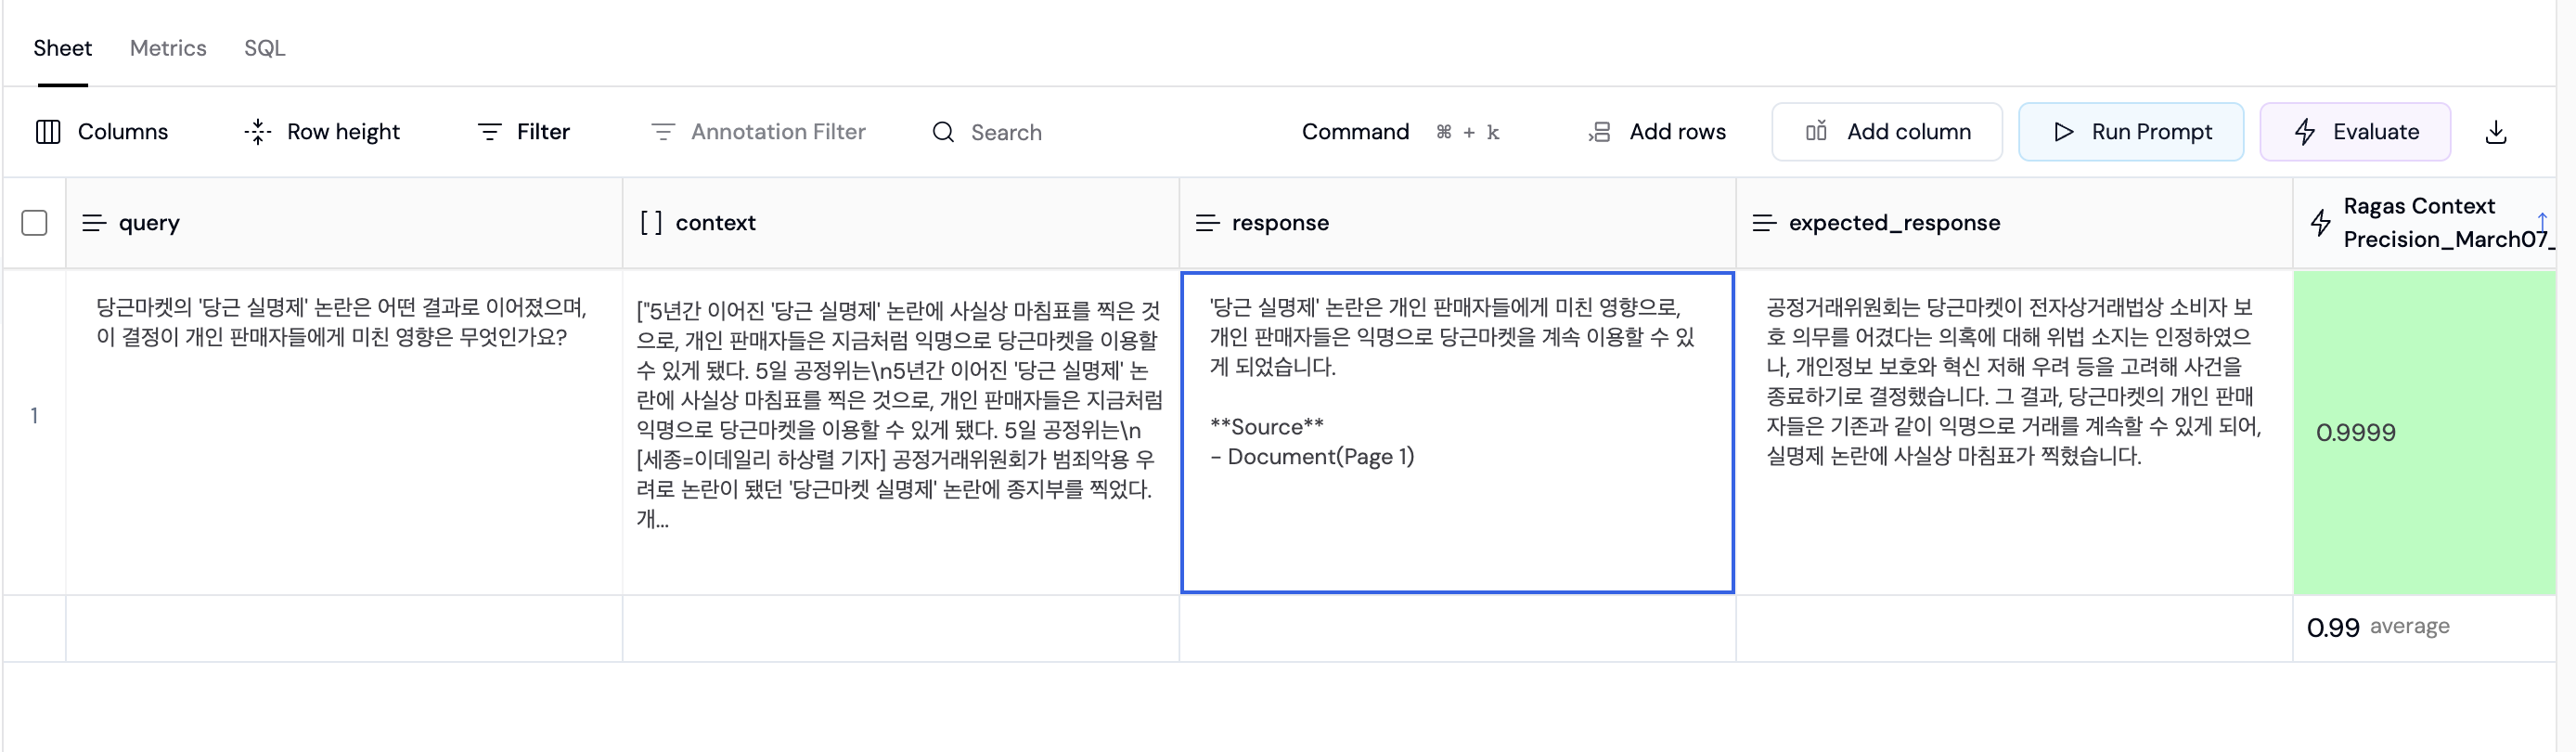